# Federated Learning — TB X-Ray Classification
### ConvNeXt Architecture + Top-K Gradient Compression + Adaptive Aggregation
**Dataset loaded from Kaggle → Google Drive (same as original pipeline)**

## STEP 1 — Install Kaggle & Download Dataset to Google Drive

In [49]:
!pip install -q kaggle

In [50]:
# Kaggle credentials (same as your original notebook)
import json, os
token = {"username": "MisbahKhannn", "key": "KGAT_931df88c82eca673cdf95776e28b540d"}
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(token, f)
!chmod 600 ~/.kaggle/kaggle.json

In [51]:
# Mount Google Drive and download the TB dataset into it
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Downloads unzip into: /content/drive/MyDrive/fl_data/TB_Chest_Radiography_Database/
# !kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset \
#     -p /content/drive/MyDrive/fl_data --unzip

# Optional extras (comment out if you only need TB)
# !kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri \
#     -p /content/drive/MyDrive/fl_data --unzip

!kaggle datasets download -d sovitrath/diabetic-retinopathy-224x224-2019-data \
    -p /content/drive/MyDrive/fl_data --unzip

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data
License(s): CC0-1.0
diabetic-retinopathy-224x224-2019-data.zip: Skipping, found more recently modified local copy (use --force to force download)


## STEP 2 — Imports

In [52]:
import os, copy, random, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from collections import defaultdict, OrderedDict
from dataclasses import dataclass, field
from typing import List
from PIL import Image, UnidentifiedImageError
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## STEP 3 — Configuration
**Only change `dataset_name` to switch datasets. Everything else is automatic.**

REPLACE STEP 3 — Config (add mu for FedProx, tune compression):

In [53]:
#  #@dataclass
# class Config:
#     # ------- DATASET -------
#     # Options: "tb_xray"  |  "brain_tumor"  |  "diabetic_retinopathy"
#     dataset_name : str   = "tb_xray"

#     # Root = where Kaggle unzipped the files inside your Drive
#     data_root    : str   = "/content/drive/MyDrive/fl_data"

#     # ------- MODEL ---------
#     img_size     : int   = 224

#     # ------- FEDERATED -----
#     num_clients  : int   = 5
#     num_rounds   : int   = 20
#     local_epochs : int   = 3
#     batch_size   : int   = 32

#     # ------- AGGREGATION ---
#     div_threshold: float = 0.15   # above = FedSGD, below = FedAvg
#     compression  : float = 0.10   # keep top 10% of gradients

#     # ------- OPTIMIZER -----
#     lr           : float = 1e-3
#     weight_decay : float = 1e-4

#     # ------- SPLIT ---------
#     dirichlet_alpha : float = 0.5   # Non-IID degree (lower = more skewed)
#     train_ratio     : float = 0.70
#     val_ratio       : float = 0.15  # test = remaining 15%

#     seed : int = 42


# cfg = Config()

# random.seed(cfg.seed)
# np.random.seed(cfg.seed)
# torch.manual_seed(cfg.seed)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(cfg.seed)

# print(f"Dataset : {cfg.dataset_name}")
# print(f"Data root: {cfg.data_root}")
@dataclass
class Config:
    dataset_name : str   = "diabetic_retinopathy"
    data_root    : str   = "/content/drive/MyDrive/fl_data"
    img_size     : int   = 224
    num_clients  : int   = 5
    num_rounds   : int   = 40
    # local_epochs : int   = 3
    local_epochs : int   = 5      # more local steps per round to compensate
    batch_size   : int   = 32
    div_threshold: float = 0.15 # cosine dissimilarity scale pe
    compression  : float = 0.10
    # lr           : float = 1e-3
    # weight_decay : float = 1e-4
    lr           : float = 3e-4   # fine-tuning rate for pretrained backbone
    weight_decay : float = 5e-4   # slightly stronger regularization
    dirichlet_alpha : float = 0.5
    train_ratio     : float = 0.70
    val_ratio       : float = 0.15
    seed : int = 42
    # ── NEW: FedProx proximal coefficient ──────────────────────────────
    mu   : float = 0.01   # 0.0 = plain FedAvg; 0.01 recommended for Non-IID

cfg = Config()
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(cfg.seed)
print(f"Dataset : {cfg.dataset_name}"); print(f"Data root: {cfg.data_root}")

Dataset : diabetic_retinopathy
Data root: /content/drive/MyDrive/fl_data


## STEP 4 — Dataset Loading from Google Drive

After the Kaggle download the folder structure inside `fl_data/` looks like:
```
fl_data/
  TB_Chest_Radiography_Database/      <-- tb_xray
      Normal/
      Tuberculosis/
  Training/                            <-- brain_tumor (train)
  Testing/                             <-- brain_tumor (test)
  colored_images/                      <-- diabetic_retinopathy
```
The code below reads **directly from those Drive folders** — no copying needed.

In [54]:
# Maps dataset names to the subfolder names that Kaggle creates
DATASET_PATHS = {
    "tb_xray": {
        "train": "TB_Chest_Radiography_Database",
        "test" : None,      # no separate test folder -> will split automatically
    },
    "brain_tumor": {
        "train": "Training",
        "test" : "Testing",
    },
    "diabetic_retinopathy": {
        "train": "colored_images",
        "test" : None,
    },
}


def get_transforms(img_size, split):
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    if split == "train":
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(0.3, 0.3, 0.2),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.2),
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


class SafeImageFolder(ImageFolder):
    """Skips corrupted images instead of crashing."""
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except (UnidentifiedImageError, OSError):
            img = Image.new('RGB', (224, 224), (0, 0, 0))
            if self.transform:
                img = self.transform(img)
            return img, 0


def load_full_dataset(cfg):
    """
    Reads images from Google Drive path.
    Returns (train_dataset, test_dataset, num_classes).

    For tb_xray / diabetic_retinopathy: auto-splits 70/15/15 (stratified).
    For brain_tumor: uses the separate Training/ and Testing/ folders.
    """
    info       = DATASET_PATHS[cfg.dataset_name]
    train_path = os.path.join(cfg.data_root, info["train"])

    print(f"Reading from: {train_path}")
    assert os.path.isdir(train_path), (
        f"Folder not found: {train_path}\n"
        "Make sure the Kaggle download finished and Drive is mounted."
    )

    full_train  = SafeImageFolder(train_path, transform=get_transforms(cfg.img_size, "train"))
    num_classes = len(full_train.classes)
    print(f"Classes ({num_classes}): {full_train.classes}")
    print(f"Total images     : {len(full_train)}")

    if info["test"] is not None:
        # Dataset ships with a separate test folder (brain_tumor)
        test_path = os.path.join(cfg.data_root, info["test"])
        test_ds   = SafeImageFolder(test_path, transform=get_transforms(cfg.img_size, "val"))
        return full_train, test_ds, num_classes

    # Auto-split (tb_xray, diabetic_retinopathy)
    indices   = list(range(len(full_train)))
    test_frac = 1.0 - cfg.train_ratio - cfg.val_ratio   # 0.15
    train_idx, test_idx = train_test_split(
        indices, test_size=test_frac * 2,               # 0.30 -> later split is 50/50
        stratify=full_train.targets, random_state=cfg.seed
    )
    test_base = SafeImageFolder(train_path, transform=get_transforms(cfg.img_size, "val"))
    return Subset(full_train, train_idx), Subset(test_base, test_idx), num_classes


train_dataset, test_dataset, NUM_CLASSES = load_full_dataset(cfg)
print(f"\nTrain samples: {len(train_dataset)}")
print(f"Test  samples: {len(test_dataset)}")
print(f"Num classes  : {NUM_CLASSES}")

Reading from: /content/drive/MyDrive/fl_data/colored_images
Classes (5): ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Total images     : 3662

Train samples: 2563
Test  samples: 1099
Num classes  : 5


## STEP 5 — Non-IID Dirichlet Partition Among Clients

In [55]:
def get_targets(ds):
    if isinstance(ds, Subset):
        return [ds.dataset.targets[i] for i in ds.indices]
    return ds.targets


def dirichlet_partition(targets, num_clients, alpha, seed):
    np.random.seed(seed)
    targets     = np.array(targets)
    num_classes = len(np.unique(targets))
    class_idx   = {c: np.where(targets == c)[0].tolist() for c in range(num_classes)}
    for c in class_idx:
        random.shuffle(class_idx[c])

    client_indices = defaultdict(list)
    for c, idx_list in class_idx.items():
        props  = np.random.dirichlet([alpha] * num_clients)
        splits = (props / props.sum() * len(idx_list)).astype(int)
        splits[-1] = len(idx_list) - splits[:-1].sum()
        ptr = 0
        for k in range(num_clients):
            client_indices[k].extend(idx_list[ptr: ptr + splits[k]])
            ptr += splits[k]
    return dict(client_indices)


train_targets = get_targets(train_dataset)
partition     = dirichlet_partition(train_targets, cfg.num_clients,
                                    cfg.dirichlet_alpha, cfg.seed)


def make_client_loader(local_indices):
    # Map local partition indices to absolute dataset indices
    if isinstance(train_dataset, Subset):
        abs_idx = [train_dataset.indices[i] for i in local_indices]
        subset  = Subset(train_dataset.dataset, abs_idx)
    else:
        subset  = Subset(train_dataset, local_indices)
    return DataLoader(subset, batch_size=cfg.batch_size, shuffle=True,
                      num_workers=2, pin_memory=torch.cuda.is_available())


client_loaders = [make_client_loader(partition[k]) for k in range(cfg.num_clients)]
test_loader    = DataLoader(test_dataset, batch_size=64, shuffle=False,
                            num_workers=2, pin_memory=torch.cuda.is_available())

for k in range(cfg.num_clients):
    print(f"  Client {k}: {len(client_loaders[k].dataset):>5} samples")
print(f"  Test   : {len(test_loader.dataset):>5} samples")

  Client 0:   476 samples
  Client 1:   955 samples
  Client 2:   264 samples
  Client 3:   126 samples
  Client 4:   742 samples
  Test   :  1099 samples


## STEP 6 — ConvNeXt Model (upgraded backbone)

REPLACE STEP 6 — Model Definition (ResNet-18 + CBAM):

In [56]:
# class ConvNeXtBlock(nn.Module):
#     """Depthwise-separable ConvNeXt block — stronger than ResNet layers."""
#     def __init__(self, dim):
#         super().__init__()
#         self.dwconv  = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
#         self.norm    = nn.LayerNorm(dim, eps=1e-6)
#         self.pwconv1 = nn.Linear(dim, 4 * dim)
#         self.act     = nn.GELU()
#         self.pwconv2 = nn.Linear(4 * dim, dim)

#     def forward(self, x):
#         residual = x
#         x = self.dwconv(x)
#         x = x.permute(0, 2, 3, 1)      # NCHW -> NHWC
#         x = self.norm(x)
#         x = self.pwconv1(x)
#         x = self.act(x)
#         x = self.pwconv2(x)
#         x = x.permute(0, 3, 1, 2)      # NHWC -> NCHW
#         return residual + x


# class MedicalClassifier(nn.Module):
#     """
#     ConvNeXt-style medical image classifier.
#     Input  : (B, 3, 224, 224)
#     Output : (B, num_classes)
#     """
#     def __init__(self, num_classes=2, dropout=0.3):
#         super().__init__()
#         self.stem = nn.Sequential(
#             nn.Conv2d(3, 64, kernel_size=4, stride=4),          # 224 -> 56
#             nn.LayerNorm([64, 56, 56], eps=1e-6)
#         )
#         self.stages = nn.ModuleList([
#             nn.Sequential(*[ConvNeXtBlock(64) for _ in range(2)]),              # 56x56
#             nn.Sequential(
#                 nn.Conv2d(64, 128, kernel_size=2, stride=2),                    # 56 -> 28
#                 nn.LayerNorm([128, 28, 28], eps=1e-6),
#                 *[ConvNeXtBlock(128) for _ in range(2)]
#             ),
#             nn.Sequential(
#                 nn.Conv2d(128, 256, kernel_size=2, stride=2),                   # 28 -> 14
#                 nn.LayerNorm([256, 14, 14], eps=1e-6),
#                 *[ConvNeXtBlock(256) for _ in range(3)]
#             ),
#         ])
#         self.head = nn.Sequential(
#             nn.AdaptiveAvgPool2d(1),
#             nn.Flatten(),
#             nn.LayerNorm(256),
#             nn.Dropout(dropout),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         x = self.stem(x)
#         for stage in self.stages:
#             x = stage(x)
#         return self.head(x)


# # Quick check — uses the real num_classes from your dataset
# _m   = MedicalClassifier(num_classes=NUM_CLASSES)
# _out = _m(torch.zeros(2, 3, 224, 224))
# print(f"Output shape : {_out.shape}  (batch=2, classes={NUM_CLASSES})  OK")
# print(f"Parameters   : {sum(p.numel() for p in _m.parameters()):,}")
# del _m, _out

import torchvision.models as tvm

# ─────────────────────────────────────────────────────────────────────────────
# CBAM: Convolutional Block Attention Module
# Adds channel + spatial attention to any ResNet feature map.
# Woo et al., ECCV 2018 — tiny parameter overhead (~0.1% of ResNet-18)
# ─────────────────────────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * scale


class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.sa(self.ca(x))


# ─────────────────────────────────────────────────────────────────────────────
# ResNet-18 + CBAM Medical Classifier
# Uses pretrained ImageNet weights → strong generalization across all datasets
# CBAM inserted after layer2 and layer4 → spatial focus for tumor localization
# ─────────────────────────────────────────────────────────────────────────────
class MedicalClassifier(nn.Module):
    """
    ResNet-18 backbone + CBAM attention.
    Input  : (B, 3, 224, 224)
    Output : (B, num_classes)
    """
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        base = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)

        # Freeze only the first conv + bn (stem) — speeds up training,
        # keeps learned low-level edge detectors
        for name, param in base.named_parameters():
            if name.startswith(("conv1", "bn1")):
                param.requires_grad = False

        self.stem   = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1                          # 64 ch,  56x56
        self.layer2 = base.layer2                          # 128 ch, 28x28
        self.cbam2  = CBAM(128)                            # ← spatial attention
        self.layer3 = base.layer3                          # 256 ch, 14x14
        self.layer4 = base.layer4                          # 512 ch,  7x7
        self.cbam4  = CBAM(512)                            # ← spatial attention

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(512),                             # stabilizes FL aggregation
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.cbam2(self.layer2(x))
        x = self.layer3(x)
        x = self.cbam4(self.layer4(x))
        return self.head(x)


# Quick sanity check
_m   = MedicalClassifier(num_classes=NUM_CLASSES)
_out = _m(torch.zeros(2, 3, 224, 224))
print(f"Output shape : {_out.shape}  (batch=2, classes={NUM_CLASSES})  OK")
print(f"Parameters   : {sum(p.numel() for p in _m.parameters()):,}")
print(f"Trainable    : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _out

Output shape : torch.Size([2, 5])  (batch=2, classes=5)  OK
Parameters   : 11,345,161
Trainable    : 11,335,625


## STEP 7 — FL Utilities (Top-K compression + FedAvg / FedSGD)

In [57]:
def topk_compress(gradients, sparsity=0.1):
    """Zero out all but the top-sparsity fraction of gradient magnitudes."""
    compressed = {}
    for name, grad in gradients.items():
        if grad is None:
            compressed[name] = None
            continue
        flat = grad.flatten()
        k    = max(1, int(flat.numel() * sparsity))
        _, idx = torch.topk(flat.abs(), k)
        out  = torch.zeros_like(flat)
        out[idx] = flat[idx]
        compressed[name] = out.reshape(grad.shape)
    return compressed
# def calc_divergence(cg, gg):
#     total, n = 0.0, 0
#     for k in gg:
#         if cg.get(k) is not None and gg.get(k) is not None:
#             diff = (cg[k].float() - gg[k].float()).norm().item()
#             norm = gg[k].float().norm().item() + 1e-8
#             total += diff / norm
#             n += 1
#     return total / max(n, 1)

def calc_divergence(cg, gg):
    total, n = 0.0, 0
    for k in gg:
        if cg.get(k) is not None and gg.get(k) is not None:
            total += torch.norm(cg[k] - gg[k]).item()
            n     += 1
    return total / max(n, 1)
# def calc_divergence(cg, gg):
#     """
#     Cosine dissimilarity between client and global gradients.
#     Range: 0 (identical) to 1 (orthogonal) to 2 (opposite)
#     More sensitive than L2 norm on sparse gradients.
#     """
#     total, n = 0.0, 0
#     for k in gg:
#         if cg.get(k) is not None and gg.get(k) is not None:
#             c_flat = cg[k].flatten().float()
#             g_flat = gg[k].flatten().float()
#             cos_sim = torch.nn.functional.cosine_similarity(
#                 c_flat.unsqueeze(0), g_flat.unsqueeze(0)
#             ).item()
#             total += (1.0 - cos_sim)   # dissimilarity
#             n     += 1
#     return total / max(n, 1)
# def calc_divergence(cg, gg):
#     total, n = 0.0, 0
#     for k in gg:
#         if cg.get(k) is not None and gg.get(k) is not None:
#             diff = (cg[k].float() - gg[k].float()).norm().item()
#             norm = gg[k].float().norm().item() + 1e-8
#             total += diff / norm
#             n += 1
#     return total / max(n, 1)


def fedavg(client_weights, client_sizes):
    total = sum(client_sizes)
    avg   = OrderedDict()
    for key in client_weights[0]:
        avg[key] = sum(w[key] * (s / total) for w, s in zip(client_weights, client_sizes))
    return avg


def fedsgd(client_grads):
    avg = {}
    for key in client_grads[0]:
        if client_grads[0][key] is not None:
            avg[key] = sum(g[key] for g in client_grads) / len(client_grads)
    return avg


print("FL utilities ready")

FL utilities ready


## STEP 8 — Client Training

REPLACE STEP 8 — Client Training (add FedProx proximal term):

In [58]:
# def train_client(client_id, model_state, loader, epochs, lr, num_classes):
#     model = MedicalClassifier(num_classes=num_classes).to(device)
#     model.load_state_dict(model_state)

#     optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
#                                   weight_decay=cfg.weight_decay)
#     scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
#     criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

#     model.train()
#     for _ in range(epochs):
#         for images, labels in loader:
#             images, labels = images.to(device), labels.to(device)
#             optimizer.zero_grad()
#             loss = criterion(model(images), labels)
#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#             optimizer.step()
#         scheduler.step()

#     grads = {
#         n: p.grad.clone().cpu() if p.grad is not None else None
#         for n, p in model.named_parameters()
#     }
#     return model.state_dict(), grads, len(loader.dataset)


# print("Client trainer ready")

def train_client(client_id, model_state, loader, epochs, lr, num_classes,
                 global_state=None, mu=0.0):
    """
    FedProx client: adds proximal term  (mu/2)*||w - w_global||^2
    when mu > 0. Falls back to standard FedAvg when mu=0.
    """
    model = MedicalClassifier(num_classes=num_classes).to(device)
    model.load_state_dict(model_state)

    # Keep a frozen copy of global weights for the proximal term
    if mu > 0.0 and global_state is not None:
        global_params = {n: p.clone().detach().to(device)
                         for n, p in MedicalClassifier(num_classes).to(device).named_parameters()
                         if p.requires_grad}
        # Load global state into it
        _tmp = MedicalClassifier(num_classes).to(device)
        _tmp.load_state_dict(global_state)
        global_params = {n: p.clone().detach() for n, p in _tmp.named_parameters()}
        del _tmp

    # optimizer = torch.optim.AdamW(
    #     filter(lambda p: p.requires_grad, model.parameters()),
    #     lr=lr, weight_decay=cfg.weight_decay
    # )
    backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and not n.startswith("head")]
    head_params     = [p for n, p in model.named_parameters()
                   if p.requires_grad and n.startswith("head")]

    optimizer = torch.optim.AdamW([
      {"params": backbone_params, "lr": lr * 0.1},   # 3e-5 — backbone gentle
      {"params": head_params,     "lr": lr},          # 3e-4 — head fast
    ], weight_decay=cfg.weight_decay)

    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
#     scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=2, T_mult=1, eta_min=1e-6
# )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs * 2, eta_min=1e-6
)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

#     # REPLACE this:
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# # WITH this:
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=2, T_mult=1, eta_min=1e-6
# )
# # REPLACE:
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=2, T_mult=1, eta_min=1e-6
# )

# # WITH: One smooth cosine decay — no restarts
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer, T_max=epochs * 2, eta_min=1e-6
# )

    model.train()
    for _ in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            loss = criterion(model(images), labels)

            # ── FedProx proximal term ──────────────────────────────────
            if mu > 0.0 and global_state is not None:
                prox = sum(
                    torch.norm(p - global_params[n].to(device)) ** 2
                    for n, p in model.named_parameters()
                    if n in global_params
                )
                loss = loss + (mu / 2.0) * prox
            # ──────────────────────────────────────────────────────────

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

    grads = {
        n: p.grad.clone().cpu() if p.grad is not None else None
        for n, p in model.named_parameters()
    }
    return model.state_dict(), grads, len(loader.dataset)


print("Client trainer (FedProx) ready")

Client trainer (FedProx) ready


## STEP 9 — Federated Orchestrator

REPLACE STEP 9 — Federated Orchestrator (pass global state + mu to clients):

In [59]:
# class FederatedLearning:
#     def __init__(self, num_classes, cfg):
#         self.global_model = MedicalClassifier(num_classes).to(device)
#         self.num_classes  = num_classes
#         self.cfg          = cfg
#         self.global_grads = None
#         self.history      = []   # (round, divergence, accuracy, loss)

#     def train_round(self, client_loaders):
#         global_state = copy.deepcopy(self.global_model.state_dict())

#         # Sequential client training (GPU parallelism happens inside each client via batching)
#         results = [
#             train_client(k, copy.deepcopy(global_state), cl,
#                          self.cfg.local_epochs, self.cfg.lr, self.num_classes)
#             for k, cl in enumerate(client_loaders)
#         ]
#         weights, grads, sizes = zip(*results)

#         # Top-K compression
#         c_grads = [topk_compress(g, self.cfg.compression) for g in grads]

#         avg_div  = 0.0
#         strategy = "FedAvg(init)"

#         if self.global_grads is None:
#             new_w = fedavg(weights, sizes)
#             self.global_grads = c_grads[0]
#         else:
#             avg_div = float(np.mean([calc_divergence(cg, self.global_grads) for cg in c_grads]))
#             if avg_div > self.cfg.div_threshold:
#                 ag    = fedsgd(c_grads)
#                 new_w = OrderedDict()
#                 for k in global_state:
#                     new_w[k] = global_state[k] - ag[k].to(device) if k in ag else global_state[k]
#                 strategy = "FedSGD"
#             else:
#                 new_w    = fedavg(weights, sizes)
#                 strategy = "FedAvg"
#             self.global_grads = fedsgd(c_grads)

#         self.global_model.load_state_dict(new_w)
#         return avg_div, strategy

#     def evaluate(self, loader):
#         self.global_model.eval()
#         crit = nn.CrossEntropyLoss()
#         correct, total, loss_sum = 0, 0, 0.0
#         with torch.no_grad():
#             for imgs, lbls in loader:
#                 imgs, lbls = imgs.to(device), lbls.to(device)
#                 out      = self.global_model(imgs)
#                 loss_sum += crit(out, lbls).item() * lbls.size(0)
#                 correct  += (out.argmax(1) == lbls).sum().item()
#                 total    += lbls.size(0)
#         return correct / total, loss_sum / total


# print("Orchestrator ready")

class FederatedLearning:
    def __init__(self, num_classes, cfg):
        self.global_model = MedicalClassifier(num_classes).to(device)
        self.num_classes  = num_classes
        self.cfg          = cfg
        self.global_grads = None
        self.history      = []

    def train_round(self, client_loaders):
        global_state = copy.deepcopy(self.global_model.state_dict())

        # ── Pass global_state + mu so clients can apply FedProx ──────────
        results = [
            train_client(k, copy.deepcopy(global_state), cl,
                         self.cfg.local_epochs, self.cfg.lr, self.num_classes,
                         global_state=global_state, mu=self.cfg.mu)
            for k, cl in enumerate(client_loaders)
        ]
        weights, grads, sizes = zip(*results)

        # Top-K gradient compression (PDC: communication efficiency)
        c_grads = [topk_compress(g, self.cfg.compression) for g in grads]

        avg_div  = 0.0
        strategy = "FedAvg(init)"

        if self.global_grads is None:
            new_w = fedavg(weights, sizes)
            self.global_grads = c_grads[0]
        else:
            avg_div = float(np.mean(
                [calc_divergence(cg, self.global_grads) for cg in c_grads]
            ))
            if avg_div > self.cfg.div_threshold:
                ag    = fedsgd(c_grads)
                new_w = OrderedDict()
                for k in global_state:
                    new_w[k] = global_state[k] - ag[k].to(device) if k in ag else global_state[k]
                strategy = "FedSGD"
            else:
                new_w    = fedavg(weights, sizes)
                strategy = "FedAvg"
            self.global_grads = fedsgd(c_grads)

        self.global_model.load_state_dict(new_w)
        return avg_div, strategy

    def evaluate(self, loader):
        self.global_model.eval()
        crit = nn.CrossEntropyLoss()
        correct, total, loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for imgs, lbls in loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out       = self.global_model(imgs)
                loss_sum += crit(out, lbls).item() * lbls.size(0)
                correct  += (out.argmax(1) == lbls).sum().item()
                total    += lbls.size(0)
        return correct / total, loss_sum / total


print("Orchestrator (FedProx + Top-K + Adaptive Aggregation) ready")

Orchestrator (FedProx + Top-K + Adaptive Aggregation) ready


## STEP 10 — Run Federated Training

In [60]:
# fl = FederatedLearning(num_classes=NUM_CLASSES, cfg=cfg)

# print("=" * 70)
# print(f" Federated Training | Dataset: {cfg.dataset_name} | "
#       f"Clients: {cfg.num_clients} | Rounds: {cfg.num_rounds}")
# print("=" * 70)

# for rnd in range(1, cfg.num_rounds + 1):
#     div, strategy = fl.train_round(client_loaders)

#     if rnd % 5 == 0 or rnd == 1:
#         acc, loss = fl.evaluate(test_loader)
#         fl.history.append((rnd, div, acc, loss))
#         print(f"Round {rnd:>3} | {strategy:<13} | Div: {div:.4f} | "
#               f"Acc: {acc*100:.2f}% | Loss: {loss:.4f}")
#     else:
#         print(f"Round {rnd:>3} | {strategy:<13} | Div: {div:.4f}")

# print("=" * 70)

fl = FederatedLearning(num_classes=NUM_CLASSES, cfg=cfg)

best_acc = 0.0
best_state = None

print("=" * 70)
print(f" Federated Training | Dataset: {cfg.dataset_name} | "
      f"Clients: {cfg.num_clients} | Rounds: {cfg.num_rounds}")
print("=" * 70)
for rnd in range(1, cfg.num_rounds + 1):
    div, strategy = fl.train_round(client_loaders)

    if rnd % 5 == 0 or rnd == 1:
        acc, loss = fl.evaluate(test_loader)
        fl.history.append((rnd, div, acc, loss))

        # ── Save best model ──────────────────────────────────────
        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(fl.global_model.state_dict())
            print(f"Round {rnd:>3} | {strategy:<13} | Div: {div:.4f} | "
                  f"Acc: {acc*100:.2f}% | Loss: {loss:.4f}  ← BEST")
        else:
            print(f"Round {rnd:>3} | {strategy:<13} | Div: {div:.4f} | "
                  f"Acc: {acc*100:.2f}% | Loss: {loss:.4f}")
    else:
        print(f"Round {rnd:>3} | {strategy:<13} | Div: {div:.4f}")

# Restore best weights at end
fl.global_model.load_state_dict(best_state)
print("=" * 70)
print(f"Best Accuracy Achieved: {best_acc*100:.2f}%")

 Federated Training | Dataset: diabetic_retinopathy | Clients: 5 | Rounds: 40
Round   1 | FedAvg(init)  | Div: 0.0000 | Acc: 71.16% | Loss: 0.8115  ← BEST
Round   2 | FedAvg        | Div: 0.0935
Round   3 | FedAvg        | Div: 0.0700
Round   4 | FedAvg        | Div: 0.0652
Round   5 | FedAvg        | Div: 0.0716 | Acc: 79.16% | Loss: 0.6083  ← BEST
Round   6 | FedAvg        | Div: 0.0688
Round   7 | FedAvg        | Div: 0.0724
Round   8 | FedAvg        | Div: 0.0719
Round   9 | FedAvg        | Div: 0.0726
Round  10 | FedAvg        | Div: 0.0716 | Acc: 80.44% | Loss: 0.5740  ← BEST
Round  11 | FedAvg        | Div: 0.0639
Round  12 | FedAvg        | Div: 0.0706
Round  13 | FedAvg        | Div: 0.0722
Round  14 | FedAvg        | Div: 0.0725
Round  15 | FedAvg        | Div: 0.0717 | Acc: 80.07% | Loss: 0.5655
Round  16 | FedAvg        | Div: 0.0715
Round  17 | FedAvg        | Div: 0.0647
Round  18 | FedAvg        | Div: 0.0658
Round  19 | FedAvg        | Div: 0.0712
Round  20 | FedAvg    

## STEP 11 — Save Training Log to CSV (Google Drive)

In [61]:
# ── Save training log to CSV (same as original notebook's save_logs()) ──
import csv

def save_logs(history, path):
    """
    Saves per-round metrics to a CSV file.
    Columns: round, divergence, accuracy, loss, strategy
    Saved to Google Drive so it persists after Colab disconnects.
    """
    with open(path, 'w', newline='') as f:
        fieldnames = ['round', 'divergence', 'accuracy_%', 'loss', 'strategy']
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for rnd, div, acc, loss in fl.history:
            # Find which strategy was used this round
            strategy = 'FedSGD' if div > cfg.div_threshold else 'FedAvg'
            writer.writerow({
                'round'      : rnd,
                'divergence' : round(div, 6),
                'accuracy_%' : round(acc * 100, 4),
                'loss'       : round(loss, 6),
                'strategy'   : strategy
            })
    print(f'Log saved to: {path}')


# Save to Google Drive
log_path = f'/content/drive/MyDrive/fl_{cfg.dataset_name}_logs.csv'
save_logs(fl.history, log_path)

# Preview first few rows
import pandas as pd
df = pd.read_csv(log_path)
print(df.to_string(index=False))

Log saved to: /content/drive/MyDrive/fl_diabetic_retinopathy_logs.csv
 round  divergence  accuracy_%     loss strategy
     1    0.000000     71.1556 0.811464   FedAvg
     5    0.071583     79.1629 0.608270   FedAvg
    10    0.071620     80.4368 0.573952   FedAvg
    15    0.071681     80.0728 0.565462   FedAvg
    20    0.069488     81.8016 0.554910   FedAvg
    25    0.070334     81.8926 0.566874   FedAvg
    30    0.071800     82.4386 0.561318   FedAvg
    35    0.072210     80.8917 0.596329   FedAvg
    40    0.053905     80.8917 0.577950   FedAvg


## STEP 12 — Final Accuracy & Per-Class Report

In [62]:
final_acc, final_loss = fl.evaluate(test_loader)
print(f"Final Test Accuracy : {final_acc*100:.2f}%")
print(f"Final Test Loss     : {final_loss:.4f}\n")

# Class names
class_names = (test_dataset.dataset.classes
               if isinstance(test_dataset, Subset)
               else test_dataset.classes)

# Collect predictions
fl.global_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = fl.global_model(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

Final Test Accuracy : 82.44%
Final Test Loss     : 0.5613

                precision    recall  f1-score   support

          Mild       0.58      0.55      0.56       111
      Moderate       0.75      0.81      0.78       300
         No_DR       0.93      0.99      0.96       542
Proliferate_DR       0.83      0.45      0.59        88
        Severe       0.57      0.40      0.47        58

      accuracy                           0.82      1099
     macro avg       0.73      0.64      0.67      1099
  weighted avg       0.82      0.82      0.81      1099



## STEP 13 — Training Curve Plots

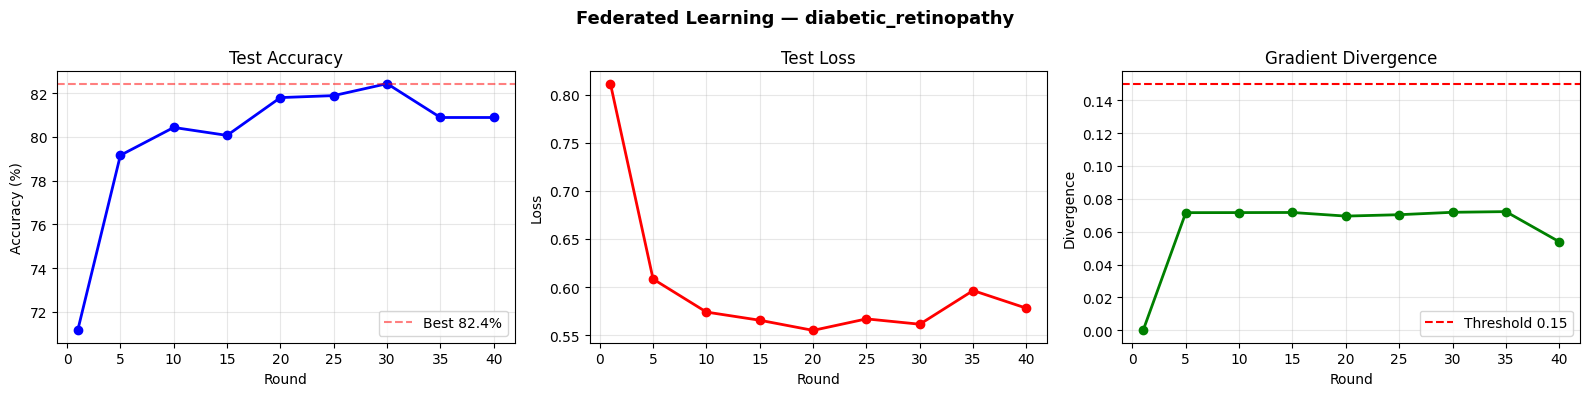

Plot saved to Google Drive


In [63]:
import matplotlib.pyplot as plt

rnds   = [h[0] for h in fl.history]
divs   = [h[1] for h in fl.history]
accs   = [h[2]*100 for h in fl.history]
losses = [h[3] for h in fl.history]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Federated Learning — {cfg.dataset_name}', fontsize=13, fontweight='bold')

axes[0].plot(rnds, accs, 'b-o', lw=2)
axes[0].axhline(max(accs), color='r', ls='--', alpha=0.5, label=f'Best {max(accs):.1f}%')
axes[0].set(title='Test Accuracy', xlabel='Round', ylabel='Accuracy (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rnds, losses, 'r-o', lw=2)
axes[1].set(title='Test Loss', xlabel='Round', ylabel='Loss')
axes[1].grid(alpha=0.3)

axes[2].plot(rnds, divs, 'g-o', lw=2)
axes[2].axhline(cfg.div_threshold, color='r', ls='--', label=f'Threshold {cfg.div_threshold}')
axes[2].set(title='Gradient Divergence', xlabel='Round', ylabel='Divergence')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
# Save to Google Drive
plt.savefig('/content/drive/MyDrive/fl_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Google Drive")

## STEP 14 — Save Model to Google Drive

In [64]:
save_path = f'/content/drive/MyDrive/fl_{cfg.dataset_name}_convnext.pth'
torch.save({
    'model_state_dict': fl.global_model.state_dict(),
    'num_classes'     : NUM_CLASSES,
    'class_names'     : class_names,
    'final_accuracy'  : final_acc,
    'rounds_trained'  : cfg.num_rounds,
}, save_path)
print(f"Model saved to: {save_path}")

# To reload:
# ckpt  = torch.load(save_path)
# model = MedicalClassifier(num_classes=ckpt['num_classes'])
# model.load_state_dict(ckpt['model_state_dict'])

Model saved to: /content/drive/MyDrive/fl_diabetic_retinopathy_convnext.pth
